# Procjena regresora

In [ ]:
from sklearn import datasets, dummy, metrics, neighbors
from sklearn import model_selection as skms
import pandas as pd
import numpy as np


In [ ]:
diabetes = datasets.load_diabetes()
tts  = skms.train_test_split(diabetes.data, diabetes.target, test_size=0.2, random_state=42)
(diabetes_train_data, diabetes_test_data, diabetes_train_target, diabetes_test_target) = tts

strategies=['constant', 'quantile', 'mean', 'median']
baseline_args = [{'strategy':s} for s in strategies]
baseline_args[0] ['constant'] = 50.0
baseline_args[1] ['quantile'] = 0.75

def do_one(**args):
    baseline = dummy.DummyRegressor(**args)
    baseline.fit(diabetes_train_data, diabetes_train_target)
    baseline_pred = baseline.predict(diabetes_test_data)
    return metrics.mean_squared_error(diabetes_test_target, baseline_pred)

mses = [do_one(**bla) for bla in baseline_args]
display(pd.DataFrame({'strategy':strategies, 'MSE':mses}))


,strategy,MSE
0,constant,14471.056180
1,quantile,9952.764045
2,mean,5361.533457
3,median,5312.404494


# Stvaranje vlastite metrike procjene

In [ ]:
def rms_error(actual, predicted):
    mse = metrics.mean_squared_error(actual, predicted)
    return np.sqrt(mse)


def neg_rmse_score(actual, predicted):
    return -rms_error(actual, predicted)


def neg_rmse_scorer(model, ftrs, tgt_actual):
    tgt_pred = model.predict(ftrs)
    return neg_rmse_score(tgt_actual, tgt_pred)

In [ ]:
diabetes = datasets.load_diabetes()
knn = neighbors.KNeighborsRegressor(n_neighbors=3)
skms.cross_val_score(knn, diabetes.data, diabetes.target, cv=5, scoring=neg_rmse_scorer)


array([-58.07341774, -67.43002106, -62.28861222, -62.02315061,
       -67.25015489])

# Ostale ugrađene regresijske metrike

### 1) R² - metoda

In [ ]:
our_preds = np.array([1,2,3])
mean_preds = np.array([2,2,2])
actual = np.array([2,3,4])

sse_ours = np.sum((our_preds - actual)**2)
sse_mean = np.sum((mean_preds - actual)**2)

r_2 = 1 - (sse_ours / sse_mean)
print(r_2)

0.4


### 2) Rezidualne plohe

In [ ]:
import matplotlib.pyplot as plt
import itertools as it
import numpy as np
import pandas as pd

def regression_errors(figsize, predicted, actual, errors='all'):
  fig, axes = plt.subplots(1, 2, figsize=figsize,
    sharex=True, sharey=True)
  df = pd.DataFrame({'actual':actual,
    'predicted':predicted})
  for ax, (x,y) in zip(axes, it.permutations(['actual',
    'predicted'])):
    # plot the data as '.'; perfect as y=x line
    ax.plot(df[x], df[y], '.', label='data')
    ax.plot(df['actual'], df['actual'], '-',
      label='perfection')
    ax.legend()
    ax.set_xlabel('{} Value'.format(x.capitalize()))
    ax.set_ylabel('{} Value'.format(y.capitalize()))
    ax.set_aspect('equal')
  axes[1].yaxis.tick_right()
  axes[1].yaxis.set_label_position("right")
  # show connecting bars from data to perfect
  # for all or only those specified?
  if errors == 'all':
    errors = range(len(df))
  if errors:
    acts = df.actual.iloc[errors]
    preds = df.predicted.iloc[errors]
    axes[0].vlines(acts, preds, acts, 'r')
    axes[1].hlines(acts, preds, acts, 'r')


         predicted  actual  error
example                          
0                4       3      1
1                2       5     -3
2                9       7      2


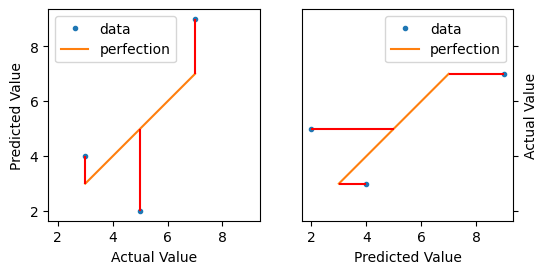

In [ ]:
ape_df = pd.DataFrame({ 'predicted': [4,2,9], 'actual': [3,5,7]})
ape_df['error'] = ape_df['predicted'] - ape_df['actual']
ape_df.index.name = 'example'
print(ape_df)

regression_errors((6,3), ape_df.predicted, ape_df.actual)

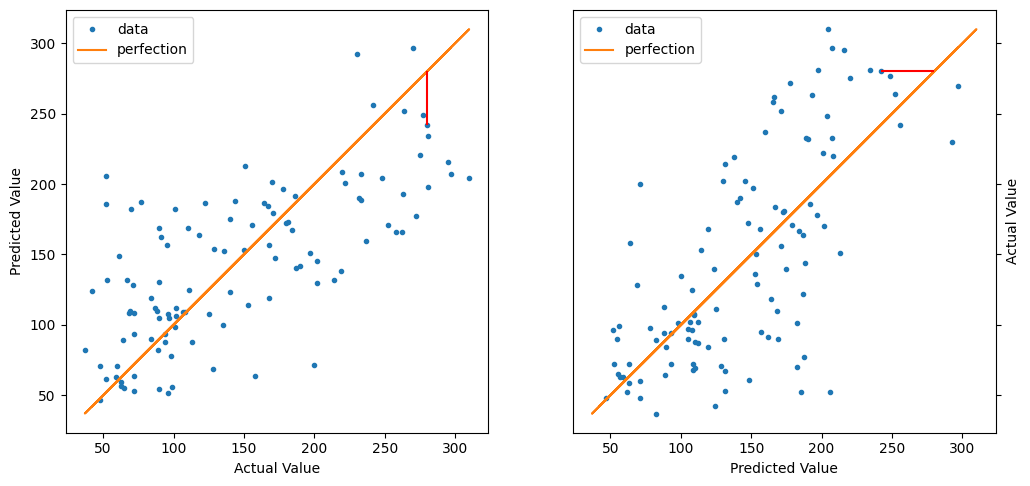

In [ ]:
from sklearn import linear_model
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split



diabetes = load_diabetes()
tts=train_test_split(diabetes.data, diabetes.target, test_size=.25, random_state=42)
(diabetes_train_data, diabetes_test_data, diabetes_train_target, diabetes_test_target) = tts

lr=linear_model.LinearRegression()
preds=(lr.fit(diabetes_train_data, diabetes_train_target).predict(diabetes_test_data))
regression_errors((12,9), preds, diabetes_test_target, errors=[-20])


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
def regression_residuals(ax, predicted, actual,
  show_errors=None, right=False):
  df = pd.DataFrame({'actual':actual,
    'predicted':predicted})
  df['error'] = df.actual - df.predicted
  ax.plot(df.predicted, df.error, '.')
  ax.plot(df.predicted, np.zeros_like(predicted), '-')
  if right:
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")
  ax.set_xlabel('Predicted Value')
  ax.set_ylabel('Residual')
  if show_errors == 'all':
    show_errors = range(len(df))
  if show_errors:
    preds = df.predicted.iloc[show_errors]
    errors = df.error.iloc[show_errors]
    ax.vlines(preds, 0, errors, 'r')



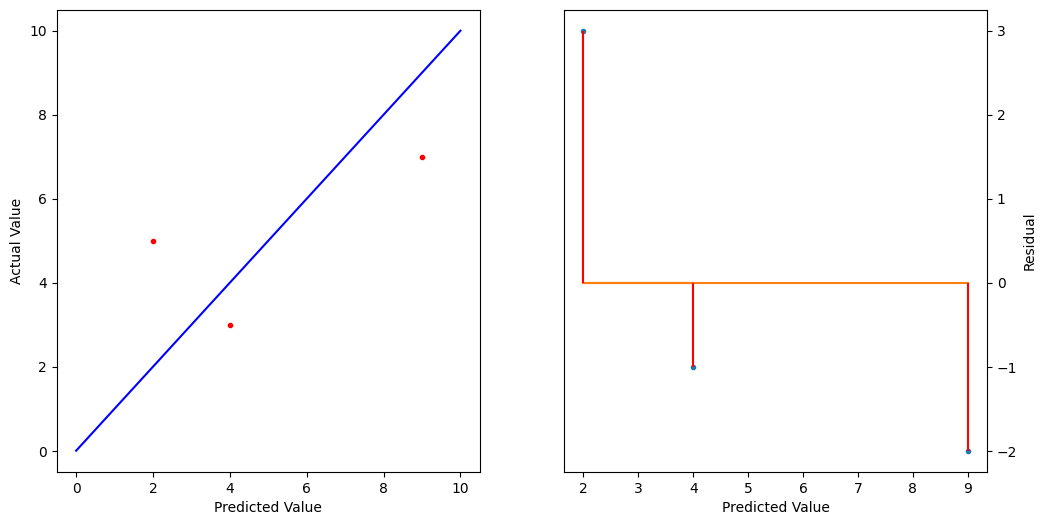

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))
ax1.plot(ape_df.predicted, ape_df.actual, 'r.', [0, 10], [0,10], 'b-')
ax1.set_xlabel('Predicted Value')
ax1.set_ylabel('Actual Value')

regression_residuals(ax2, ape_df.predicted, ape_df.actual, 'all', right=True)

Text(0.5, 1.0, 'K-Nearest Neighbors')

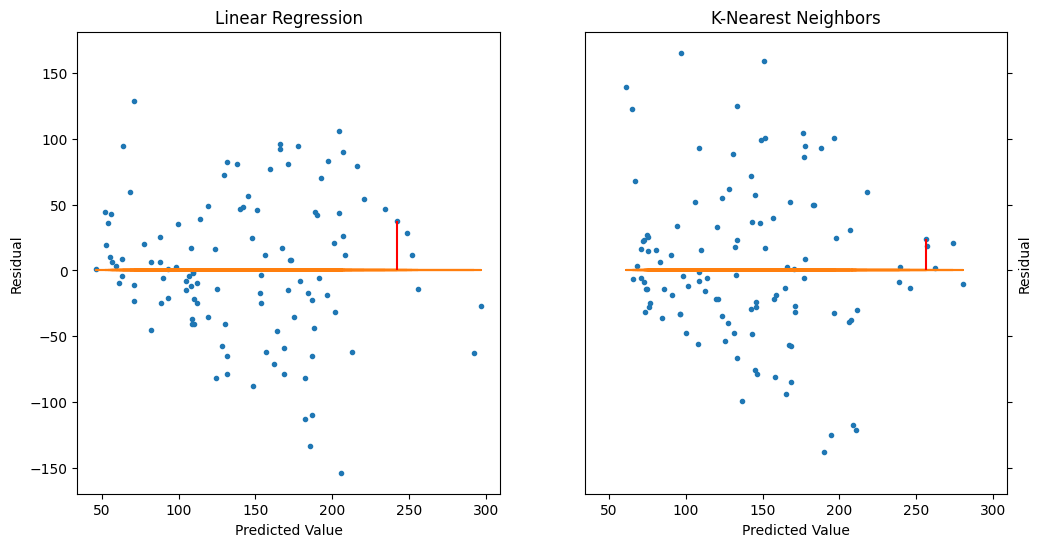

In [ ]:
from sklearn import linear_model, neighbors
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

diabetes = load_diabetes()
lr = linear_model.LinearRegression()
knn = neighbors.KNeighborsRegressor(n_neighbors=3)

models = [lr, knn]
fig, axes = plt.subplots(1, 2, figsize=(12,6), sharex=True, sharey=True)

for model, ax, on_right in zip(models, axes, [False, True]):
  preds = model.fit(diabetes_train_data, diabetes_train_target).predict(diabetes_test_data)
  regression_residuals(ax, preds, diabetes_test_target, [-20], right=on_right)

axes[0].set_title('Linear Regression')
axes[1].set_title('K-Nearest Neighbors')


### 3) Normalizacija i standrdizacija

,x,std-ized
mean,2.500000,2.220446e-17
std,4.670589,1.000000e+00


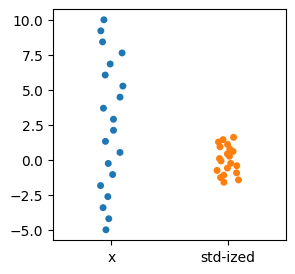

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import explained_variance_score
from sklearn.linear_model import LinearRegression
import seaborn as sns
# 1D standardization
# place evenly spaced values in a dataframe
xs = np.linspace(-5, 10, 20)
df = pd.DataFrame(xs, columns=['x'])
# center ( - mean) and scale (/ std)
df['std-ized'] = (df.x - df.x.mean()) / df.x.std()
# show original and new data; compute statistics
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
sns.stripplot(data=df)
display(df.describe().loc[['mean', 'std']])

In [ ]:
xs = np.linspace(-5, 10, 20)
ys = 3*xs + 2 + np.random.uniform(20, 40, 20)
df = pd.DataFrame({'x':xs, 'y':ys})
df_std_ized = (df - df.mean()) / df.std()
display(df_std_ized.describe().loc[['mean', 'std']])

,x,y
mean,2.220446e-17,-1.887379e-16
std,1.000000e+00,1.000000e+00


Text(0.5, 0, 'Standardized Data')

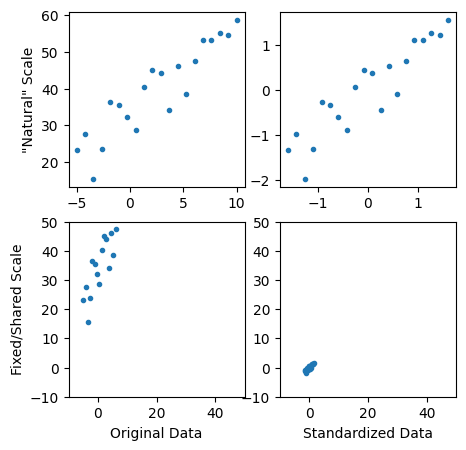

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(5, 5))
ax[0,0].plot(df.x, df.y, '.')
ax[0,1].plot(df_std_ized.x, df_std_ized.y, '.')
ax[0,0].set_ylabel('"Natural" Scale')
ax[1,0].plot(df.x, df.y, '.')
ax[1,1].plot(df_std_ized.x, df_std_ized.y, '.')
ax[1,0].axis([-10, 50, -10, 50])
ax[1,1].axis([-10, 50, -10, 50])
ax[1,0].set_ylabel('Fixed/Shared Scale')
ax[1,0].set_xlabel('Original Data')
ax[1,1].set_xlabel('Standardized Data')

In [ ]:
import sklearn.model_selection as skms
import sklearn.preprocessing as skpre

train_xs, test_xs = skms.train_test_split(xs.reshape(-1,1), test_size=0.5)
scaler = skpre.StandardScaler()
scaler.fit(train_xs).transform(test_xs)


array([[ 0.83355445],
       [ 1.00721163],
       [ 1.18086881],
       [ 0.65989728],
       [-0.90301733],
       [ 0.13892574],
       [ 1.52818317],
       [ 1.70184034],
       [-0.55570297],
       [-1.0766745 ]])

In [ ]:
from sklearn import linear_model, pipeline
(train_xs, test_xs,
  train_ys, test_ys)= skms.train_test_split(xs.reshape(-1, 1),
ys.reshape(-1, 1),
  test_size=.5)
scaler = skpre.StandardScaler()
lr = linear_model.LinearRegression()
std_lr_pipe = pipeline.make_pipeline(scaler, lr)
std_lr_pipe.fit(train_xs, train_ys).predict(test_xs)

array([[28.89258528],
       [54.35915743],
       [56.1781983 ],
       [25.25450354],
       [23.43546268],
       [27.07354441],
       [21.61642181],
       [39.80683049],
       [48.90203482],
       [36.16874875]])